# Project 2 - Utilization of hospital beds during epidemics

### Importing necessary packages

In [91]:
import numpy as np
import heapq
import time
import matplotlib.pyplot as plt

### Defining given parameters

In [56]:
start_time = 0
end_time = 365

### Ward A – Regular care
Defining the arrival rate function and length-of-stay for ward A

In [57]:
# Arrival rate function
def lambda_A(t):
    if 0 <= t <= 365: # t must be between 0 and 365
        return -(1/3650)*t**2 + (1/10)*t
    return 0    # If t is outsite the (0,365) the function returns zero

# Length-of-stay parameters
mu_A = np.log(4 * np.sqrt(2))   # The mean
sigma_A = np.sqrt(np.log(2))    # The standard deviation

### Ward B – Intensive care

Defining the arrival function and the length-of-stay for ward B

In [58]:
# The arrival rate function for ward B
def lambda_B(t):
    return (1/5) * lambda_A(t)

# The length-of-stay parameters
mu_B = np.log(6 * np.sqrt(2))   # The mean
sigma_B = np.sqrt(np.log(2))    # The standard deviation

### Ward C – Other
Defning the arrival function and the length-of stay for ward C

In [59]:
# Arrical rate (constant)
lambda_C = 6    # Assuming 6 patients per day

# Length-of-stay parameters
mu_C = np.log(5 * np.sqrt(2))   # The mean
sigma_C = np.sqrt(np.log(2))    # The standard deviation

## Primary task
Assuming the system starts in $t=0$ and ends in $t = 365$, we build a simulation model that simulates
the patient flow for all three patient types and wards as a function of the bed distribution and the
aforementioned parameters.

#### We find the maximal rate of the arrivals for the A and B patients and then look at the timesteps with this interval between them and accept with probability: lambda(t)/lambda_max

In [60]:
# The peak of a parabola occurs at t = -b / (2a)
t_max = -(1/10) / (2 * -(1/3650))   # The top of the parobola

# Plugging the peak time t into the lamdba functions to get the max rates
lambda_max_A = lambda_A(t_max)
lambda_max_B = lambda_max_A / 5.0

print(f"Peak arrival rate for patients type A is {lambda_max_A}")
print(f"Peak arrival rate for patients type B is {lambda_max_B}")

Peak arrival rate for patients type A is 9.125000000000002
Peak arrival rate for patients type B is 1.8250000000000004


Defining a function that simulates the patients flow in the hospital. It counts the number of patients that arrive of the three different types, the number of patients that are given a bed in the wanted ward as well as now many patients are relocated either to another ward or another hospital.

We use a 3x4 matrix, where the rows correspond to the patients types and the columns correspond to the ward they end up getting a bed in, column 0 is ward A, column 1 is ward B, column 2 is ward C and column 3 are patients relocated to another hospital (we can call this ward D). For example if flow_matrix[0,3] = 2 it means that two patients of type A where relocated to another hospital. flow_matrix[1,0]=4, means that 4 patients for type B got a bed in ward A.

In [76]:
# Setting seed for reproducebility
np.random.seed(2443)

def run_simulation(beds_a, beds_b, beds_c): 
    # Defining initial variables
    clock = 0.0 
    
    occupied_A = 0  # initial occupied beds in ward A
    occupied_B = 0  # initial occupied beds in ward B
    occupied_C = 0  # initial occupied beds in ward C

    # Adding trackers to calculate the mean fraction of beds that are occupied later
    last_event_time = 0.0
    area_A = 0.0
    area_B = 0.0
    area_C = 0.0


    # Initialize a 3x4 matrix with zeros
    # Rows: Intended ward (patient types) (0=A, 1=B, 2=C)
    # Columns: Actual placement (0=A, 1=B, 2=C, 3=Relocated (D))
    flow_matrix = np.zeros((3, 4), dtype=int)

    relocated = [0,0,0]     # Initilize list to count the number of relocated patients from the three patients types
    total_arrivals = [0,0,0]    # Initilize list to count the total number of arrivals of the three patients types
    
    # Initilize an list to be the event queue. The inputs in the list will be tuples of the 
    # time, event type (arrival or departure), patient type and in which ward the patient is getting a bed
    event_queue = []
    
    # Defining a helper function to predict the next arrivals
    def schedule_next_arrival(patient_type, current_time):  # Inputs are the patient type (A, B, or C) and the time
        if patient_type == 'A':
            # if the patient is of type A, the time of arrival is found using the max rate of the A type arrival
            # and accepted with probability: (lambda_A(current_time) / lambda_max_A)
            while True:
                current_time += np.random.exponential(1/lambda_max_A)
                if current_time > end_time or np.random.rand() < (lambda_A(current_time) / lambda_max_A):
                    break # If the time is outside the interval (0, 365) of if the arrival is rejected the code breaks
            if current_time <= end_time:    # is the arrival is accepted and the time is inside the imterval (0, 365)
                heapq.heappush(event_queue, (current_time, 'ARRIVAL', 'A', None))   # the next arrival is added to the event_queue list
                
        elif patient_type == 'B':
            # if the patient is of type B, the time of arrival is found using the max rate of the B type arrival
            # and accepted with probability: (lambda_A(current_time) / lambda_max_B)
            while True:
                current_time += np.random.exponential(1/lambda_max_B)
                if current_time > end_time or np.random.rand() < (lambda_B(current_time) / lambda_max_B):
                    break
            if current_time <= end_time:
                heapq.heappush(event_queue, (current_time, 'ARRIVAL', 'B', None))   # The next arrival is added to the event_queue list
        
        elif patient_type == 'C': 
            # if the patient is of type C, the time of the next arrival is found by exponentially sampling from the type C arrival rate
            next_time = current_time + np.random.exponential(1/lambda_C)
            heapq.heappush(event_queue, (next_time, 'ARRIVAL', 'C', None))  # the next arrival is added to the event_queue list

    # Simulating the first arrivals for each patient type
    schedule_next_arrival('A', clock)
    schedule_next_arrival('B', clock)
    schedule_next_arrival('C', clock)

    # The main loop
    while len(event_queue) > 0: # while there are patients in the event_queue. Patients that will arrive at a later time
        event_time, event_type, patient_type, ward = heapq.heappop(event_queue) # Excracting the time, event type, patient type and which ward the patients are in from the list
        
        clock = event_time  # Updating the time
        if clock > end_time:    
            break   # If t is larger than 365 the code breaks
            
       
        # Caclulating the elapsed time
        time_elapsed = event_time - last_event_time
        if event_time > end_time:
            time_elapsed = end_time - last_event_time
            area_A += occupied_A * time_elapsed
            area_B += occupied_B * time_elapsed
            area_C += occupied_C * time_elapsed
            break
        area_A += occupied_A * time_elapsed
        area_B += occupied_B * time_elapsed
        area_C += occupied_C * time_elapsed
        
        # Updating the times
        clock = event_time  
        last_event_time = clock

        if event_type == 'ARRIVAL': # If we have a patient arriving
            if patient_type == 'A':
                total_arrivals[0] += 1  # Updating the total number of arrived patients of patient type A
                los = np.random.lognormal(mu_A, sigma_A)    # the length of stay for a patient of type A
                if occupied_A < beds_a: 
                    # If there are beds avalible in ward A, the patients gets a bed there
                    occupied_A += 1 # Update the number of occupied beds in ward A
                    flow_matrix[0, 0] += 1  # Intended A, actually in ward A
                    # Add a new event to the event_queue list. An departure of this new patients
                    #  based on the simulated length of stay time
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'A', 'A'))
                else:
                    # if there are no availeble beds in ward A, the patient is relocated to another hospital
                    flow_matrix[0, 3] += 1  # Intended A, relocated to another hospital (we call this D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'A', 'D'))   # Add the departure event to the event_queue list
                    relocated[0] += 1
                    
            elif patient_type == 'B':
                total_arrivals[1] += 1  # Updating the total number of arrived patients of patient type B
                los = np.random.lognormal(mu_B, sigma_B)    # the length of stay for a patient of type B
                # If there are beds avalible in ward B, the patients gets a bed there
                if occupied_B < beds_b:
                    occupied_B += 1
                    flow_matrix[1, 1] += 1  # Intended B, actually in B
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'B'))
                # If there are no beds avalible in ward B, we check if there are beds avalible in ward A
                elif occupied_A < beds_a:
                    occupied_A += 1
                    flow_matrix[1, 0] += 1  # Intended B, actually in A 
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'A')) # Updating the event_quese list
                    relocated[1] += 1
                # If there are no avalible beds in neither ward B or A then the patients is relocated to another hospital (ward D)
                else:
                    flow_matrix[1, 3] += 1  # Intended B, relocated to another hospital (D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'D')) 
                    relocated[1] += 1
                    
            elif patient_type == 'C':
                total_arrivals[2] += 1  # Updating the total number of arrived patients of patient type C
                los = np.random.lognormal(mu_C, sigma_C)    # the length of stay for a patient of type C
                # If there are beds avalible in ward C, the patients gets a bed there
                if occupied_C < beds_c:
                    occupied_C += 1
                    flow_matrix[2, 2] += 1  # Intended C, actually in C
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'C', 'C'))
                else:
                    # if there are no availeble beds in ward C, the patient is relocated to another hospital
                    flow_matrix[2, 3] += 1  # Intended C, relocated to another hospital (ward D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'C', 'D'))
                    relocated[2] += 1
            
            # Schedule the next arrival using the helper function
            schedule_next_arrival(patient_type, clock)
        
        # If the event is a departure (an not an arrival)
        elif event_type == 'DEPARTURE':
            # if a patient in ward A is departuring we update the number of occupied beds counter and the flow:matrix
            # in ward A there can be patients of type A or B
            if ward == 'A':
                occupied_A -= 1
                if patient_type == 'A':
                    flow_matrix[0, 0] -= 1
                elif patient_type == 'B':
                    flow_matrix[1, 0] -= 1
            elif ward == 'B':   
                # updating the number of occupied beds in ward B is a patient is departuring from ward B
                # in ward B there can only be patients of type B
                occupied_B -= 1
                flow_matrix[1, 1] -= 1
            elif ward == 'C':
                # updating the number of occupied beds in ward C is a patient is departuring from ward B
                # in ward B there can only be patients of type C
                occupied_C -= 1
                flow_matrix[2, 2] -=1
            elif ward == "D":
                # updating the number of patients sent to another hospital at this time (column 3 in the flow_matrix)
                if patient_type == 'A':
                    flow_matrix[0, 3] -= 1
                elif patient_type == 'B':
                    flow_matrix[1, 3] -= 1
                elif patient_type == 'C':
                    flow_matrix[2, 3] -= 1
        
        # Calculating the fraction of the time the beds are occupied
        mean_util_A = (area_A / end_time) / beds_a
        mean_util_B = (area_B / end_time) / beds_b
        mean_util_C = (area_C / end_time) / beds_c

    # Returning the total number of arrivals and total number of relocated patients for the ward types A, B, C        
    return total_arrivals, relocated, (mean_util_A, mean_util_B, mean_util_C) 

In [81]:
# Testing the simulation function on a choosen bed distribution
run_simulation(30, 10, 35)

([2170, 456, 2191],
 [1122, 236, 947],
 (0.8661390567524608, 0.7689896029704678, 0.9554046974170822))

In order to make plots we make some changes to the function, so that it saved the flow_matrix in every iteration. We only use this function for the plots and not for calculations, since the first code will be faster.

In [63]:
# Seed for reproducebility
np.random.seed(2443)

def run_simulation_plot(beds_a, beds_b, beds_c): 
     # Defining initial variables
    clock = 0.0 
    
    occupied_A = 0  # initial occupied beds in ward A
    occupied_B = 0  # initial occupied beds in ward B
    occupied_C = 0  # initial occupied beds in ward C
    
    # Initialize a 3x4 matrix with zeros
    # Rows: Intended ward (patient types) (0=A, 1=B, 2=C)
    # Columns: Actual placement (0=A, 1=B, 2=C, 3=Relocated (D))
    flow_matrix = np.zeros((3, 4), dtype=int)

    # Initilize a list to store flow_matrix for all the events in
    plot_list = []
    plot_list.append((flow_matrix.copy(), clock))
    

    # Initilize an list to be the event queue. The inputs in the list will be tuples of the 
    # time, event type (arrival or departure), patient type and in which ward the patient is getting a bed
    event_queue = []
    
    # Defining a helper function to predict the next arrivals
    def schedule_next_arrival(patient_type, current_time):  # Inputs are the patient type (A, B, or C) and the time
        if patient_type == 'A':
            # if the patient is of type A, the time of arrival is found using the max rate of the A type arrival
            # and accepted with probability: (lambda_A(current_time) / lambda_max_A)
            while True:
                current_time += np.random.exponential(1/lambda_max_A)
                if current_time > end_time or np.random.rand() < (lambda_A(current_time) / lambda_max_A):
                    break # If the time is outside the interval (0, 365) of if the arrival is rejected the code breaks
            if current_time <= end_time:    # is the arrival is accepted and the time is inside the imterval (0, 365)
                heapq.heappush(event_queue, (current_time, 'ARRIVAL', 'A', None))   # the next arrival is added to the event_queue list
                
        elif patient_type == 'B':
            # if the patient is of type B, the time of arrival is found using the max rate of the B type arrival
            # and accepted with probability: (lambda_A(current_time) / lambda_max_B)
            while True:
                current_time += np.random.exponential(1/lambda_max_B)
                if current_time > end_time or np.random.rand() < (lambda_B(current_time) / lambda_max_B):
                    break
            if current_time <= end_time:
                heapq.heappush(event_queue, (current_time, 'ARRIVAL', 'B', None))   # The next arrival is added to the event_queue list
        
        elif patient_type == 'C': 
            # if the patient is of type C, the time of the next arrival is found by exponentially sampling from the type C arrival rate
            next_time = current_time + np.random.exponential(1/lambda_C)
            heapq.heappush(event_queue, (next_time, 'ARRIVAL', 'C', None))  # the next arrival is added to the event_queue list

    # Simulating the first arrivals for each patient type
    schedule_next_arrival('A', clock)
    schedule_next_arrival('B', clock)
    schedule_next_arrival('C', clock)
            

    # The main loop
    while len(event_queue) > 0: # while there are patients in the event_queue. Patients that will arrive at a later time
        event_time, event_type, patient_type, ward = heapq.heappop(event_queue) # Excracting the time, event type, patient type and which ward the patients are in from the list
        
        clock = event_time  # Updating the time
        if clock > end_time:    
            break   # If t is larger than 365 the code breaks
                           
        if event_type == 'ARRIVAL': # If we have a patient arriving
            if patient_type == 'A':
                los = np.random.lognormal(mu_A, sigma_A)    # the length of stay for a patient of type A
                if occupied_A < beds_a: 
                    # If there are beds avalible in ward A, the patients gets a bed there
                    occupied_A += 1 # Update the number of occupied beds in ward A
                    flow_matrix[0, 0] += 1  # Intended A, actually in ward A
                    # Add a new event to the event_queue list. An departure of this new patients
                    #  based on the simulated length of stay time
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'A', 'A'))
                else:
                    # if there are no availeble beds in ward A, the patient is relocated to another hospital
                    flow_matrix[0, 3] += 1  # Intended A, relocated to another hospital (we call this D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'A', 'D'))   # Add the departure event to the event_queue list
                    
            elif patient_type == 'B':
                los = np.random.lognormal(mu_B, sigma_B)    # the length of stay for a patient of type B
                # If there are beds avalible in ward B, the patients gets a bed there
                if occupied_B < beds_b:
                    occupied_B += 1
                    flow_matrix[1, 1] += 1  # Intended B, actually in B
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'B'))
                # If there are no beds avalible in ward B, we check if there are beds avalible in ward A
                elif occupied_A < beds_a:
                    occupied_A += 1
                    flow_matrix[1, 0] += 1  # Intended B, actually in A 
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'A')) # Updating the event_quese list
                # If there are no avalible beds in neither ward B or A then the patients is relocated to another hospital (ward D)
                else:
                    flow_matrix[1, 3] += 1  # Intended B, relocated to another hospital (D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'D')) 
                    
            elif patient_type == 'C':
                los = np.random.lognormal(mu_C, sigma_C)    # the length of stay for a patient of type C
                # If there are beds avalible in ward C, the patients gets a bed there
                if occupied_C < beds_c:
                    occupied_C += 1
                    flow_matrix[2, 2] += 1  # Intended C, actually in C
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'C', 'C'))
                else:
                    # if there are no availeble beds in ward C, the patient is relocated to another hospital
                    flow_matrix[2, 3] += 1  # Intended C, relocated to another hospital (ward D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'C', 'D'))
            
            # Schedule the next arrival using the helper function
            schedule_next_arrival(patient_type, clock)
        
        # If the event is a departure (an not an arrival)
        elif event_type == 'DEPARTURE':
            # if a patient in ward A is departuring we update the number of occupied beds counter and the flow:matrix
            # in ward A there can be patients of type A or B
            if ward == 'A':
                occupied_A -= 1
                if patient_type == 'A':
                    flow_matrix[0, 0] -= 1
                elif patient_type == 'B':
                    flow_matrix[1, 0] -= 1
            elif ward == 'B':   
                # updating the number of occupied beds in ward B is a patient is departuring from ward B
                # in ward B there can only be patients of type B
                occupied_B -= 1
                flow_matrix[1, 1] -= 1
            elif ward == 'C':
                # updating the number of occupied beds in ward C is a patient is departuring from ward B
                # in ward B there can only be patients of type C
                occupied_C -= 1
                flow_matrix[2, 2] -=1
            elif ward == "D":
                # updating the number of patients sent to another hospital at this time (column 3 in the flow_matrix)
                if patient_type == 'A':
                    flow_matrix[0, 3] -= 1
                elif patient_type == 'B':
                    flow_matrix[1, 3] -= 1
                elif patient_type == 'C':
                    flow_matrix[2, 3] -= 1

        # Appending the flow_matrix and the time to the plot_list
        plot_list.append((flow_matrix.copy(), clock))

    # Returning the plot_list containing the distribution of the patients for the types A, B, C        
    return plot_list  

In [65]:
# Trying to run the function for a choosen bed distribution
run_simulation_plot(30,10,35)

[(array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0]]),
  0.0),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 1, 0]]),
  0.035348128656585764),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 2, 0]]),
  0.1961498081092691),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 3, 0]]),
  0.3545794874080819),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 4, 0]]),
  0.505389641160673),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 5, 0]]),
  0.6952634908040172),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 6, 0]]),
  1.166490849812128),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 7, 0]]),
  1.3371303920432775),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 8, 0]]),
  1.6960931512497464),
 (array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 9, 0]]),
  1.993471370088485),
 (array([[ 0,  0,  0,  0],
         [ 0,  0,  0,  0],
         [ 0,  0, 10, 

## Primary performance measures
We run the simulation 100 times, and calculate the probability that all beds are occupied on arrival for each of the three patient types and the mean number of patients that are relocated due to shortage of beds.

In [ ]:
np.random.seed(2443)

N = 100 # Number of times to run the simulation

# Lists to store the number of relocated patients from the three wards
relocated_A_list = []
relocated_B_list = []
relocated_C_list = []
# Lists to store the mean fraction of occupied beds in each ward
prob_A_list = []
prob_B_list = []
prob_C_list = []

print(f"Running simulation {N} times.")

for i in range(N):
    # Run the simulation with a choosen bed distribution of (32, 10, 33)
    arrivals, relocations = run_simulation(32, 10, 33)  # Extracting the toal arrivals and relocations from the three ward types
    
    # Appending the relocated patients to the lists
    relocated_A_list.append(relocations[0])
    relocated_B_list.append(relocations[1])
    relocated_C_list.append(relocations[2])
    
    # Calculating and appending the probability that all beds are occupied (Relocated / Total Arrivals)
    prob_A_list.append(relocations[0] / arrivals[0] if arrivals[0] > 0 else 0)
    prob_B_list.append(relocations[1] / arrivals[1] if arrivals[1] > 0 else 0)
    prob_C_list.append(relocations[2] / arrivals[2] if arrivals[2] > 0 else 0)


# Printing the results
print(f"Mean Relocated A: {np.mean(relocated_A_list):.2f}")
print(f"Mean Relocated B: {np.mean(relocated_B_list):.2f}")
print(f"Mean Relocated C: {np.mean(relocated_C_list):.2f}")
total_mean_relocated = np.mean(relocated_A_list) + np.mean(relocated_B_list) + np.mean(relocated_C_list)
print(f"Mean total Relocated: {total_mean_relocated:.2f}")

print("\nThe probability that all beds are occupied:")
print(f"Ward A: {np.mean(prob_A_list):.4f} ({np.mean(prob_A_list)*100:.2f}%)")
print(f"Ward B: {np.mean(prob_B_list):.4f} ({np.mean(prob_B_list)*100:.2f}%)")
print(f"Ward C: {np.mean(prob_C_list):.4f} ({np.mean(prob_C_list)*100:.2f}%)")

Running simulation 100 times.
Mean Relocated A: 1090.41
Mean Relocated B: 205.91
Mean Relocated C: 1001.36
Mean total Relocated: 2297.68

The probability that all beds are occupied
Ward A: 0.4924 (49.24%)
Ward B: 0.4601 (46.01%)
Ward C: 0.4570 (45.70%)


## Sensitivity analysis
We test the sensitivity to the distribution of the 75 beds and try to find the optimal bed distribution
considering the sum of the relocated patients. 

We also test the system’s sensitivity on the different performance measures to the length-of-stay distribution by employing an exponential distribution instead.

Then we  evaluate the impact of increasing the total amount of beds in the system to for instance 80
or 100 beds, and also see what the impact of having fewer beds would be.

### Optimizing the 75 bed distribution by using grid search

In [75]:
np.random.seed(2443)

total_beds = 75     # The total number of beds

search_runs = 10    # We use 10 runs per combination

best_beds = (0, 0, 0)   # initial best beds distribution
min_relocated = float('inf')    # Defining an initial minimum value as infinity to be updated in the loop


start_time_search = time.time() # The starting time

# Loop through possible values for ward A (1 to 73) (73 in ward A, 1 in ward B and 1 in ward C)
for a in range(1, total_beds - 1):
    # Loop through possible values for Ward B
    for b in range(1, total_beds - a):
        # Ward C gets whatever is left
        c = total_beds - a - b
        
        # Ensure it's a valid combination
        if c > 0:
            total_relocated_current = 0
            
            # Run the simulation for this combination
            for i in range(search_runs):
                arrivals, relocations = run_simulation(a, b, c)

                # Sum up the three values in the relocations list
                total_relocated_current += sum(relocations)

            mean_relocated = total_relocated_current / search_runs

            # If this combination is the best one yet, save it and print it!
            if mean_relocated < min_relocated:
                min_relocated = mean_relocated
                best_beds = (a, b, c)
                print(f"New Best Found: A:{a:02d}, B:{b:02d}, C:{c:02d} | Mean Relocated: {min_relocated:.1f}")
            
        
print(f"\nThe optimization completed in ({time.time() - start_time_search:.1f} seconds)")
print(f"Optimal beds distribution: Ward A: {best_beds[0]}, Ward B: {best_beds[1]}, Ward C: {best_beds[2]}")
print(f"Mean minimum relocated patients: {min_relocated:.1f}")

New Best Found -> A:01, B:01, C:73 | Mean Relocated: 2626.8
New Best Found -> A:01, B:02, C:72 | Mean Relocated: 2625.2
New Best Found -> A:01, B:03, C:71 | Mean Relocated: 2600.9
New Best Found -> A:01, B:04, C:70 | Mean Relocated: 2569.1
New Best Found -> A:01, B:05, C:69 | Mean Relocated: 2552.4
New Best Found -> A:01, B:06, C:68 | Mean Relocated: 2531.1
New Best Found -> A:01, B:07, C:67 | Mean Relocated: 2518.9
New Best Found -> A:01, B:10, C:64 | Mean Relocated: 2495.7
New Best Found -> A:01, B:13, C:61 | Mean Relocated: 2490.2
New Best Found -> A:01, B:15, C:59 | Mean Relocated: 2484.7
New Best Found -> A:02, B:09, C:64 | Mean Relocated: 2482.3
New Best Found -> A:02, B:10, C:63 | Mean Relocated: 2473.6
New Best Found -> A:03, B:06, C:66 | Mean Relocated: 2467.0
New Best Found -> A:03, B:08, C:64 | Mean Relocated: 2448.0
New Best Found -> A:03, B:10, C:62 | Mean Relocated: 2435.7
New Best Found -> A:04, B:10, C:61 | Mean Relocated: 2426.5
New Best Found -> A:04, B:11, C:60 | Mea

We see that using this seed and running the function 10 times the best distribution of the 75 beds is (29, 7, 39). That is to put 29 beds in ward A, 7 beds in ward B and 39 beds in ward C.

#### Change the length-of-stay distribution to an exponential distribution instead
Now we test the system’s sensitivity on the different performance measures to the length-of-stay distribution by employing an exponential distribution instead. We do this by copying the run_simulation function, and calling it run_simulation_exp, and sampling from an exponential function with the given means (8, 12 and 10) instead, where we previously sampled from a log-normal function. 

In [82]:
# Setting seed for reproducebility
np.random.seed(2443)

def run_simulation_exp(beds_a, beds_b, beds_c): 
    # Defining initial variables
    clock = 0.0 
    
    occupied_A = 0  # initial occupied beds in ward A
    occupied_B = 0  # initial occupied beds in ward B
    occupied_C = 0  # initial occupied beds in ward C

    # Adding trackers to calculate the mean fraction of beds that are occupied later
    last_event_time = 0.0
    area_A = 0.0
    area_B = 0.0
    area_C = 0.0


    # Initialize a 3x4 matrix with zeros
    # Rows: Intended ward (patient types) (0=A, 1=B, 2=C)
    # Columns: Actual placement (0=A, 1=B, 2=C, 3=Relocated (D))
    flow_matrix = np.zeros((3, 4), dtype=int)

    relocated = [0,0,0]     # Initilize list to count the number of relocated patients from the three patients types
    total_arrivals = [0,0,0]    # Initilize list to count the total number of arrivals of the three patients types
    
    # Initilize an list to be the event queue. The inputs in the list will be tuples of the 
    # time, event type (arrival or departure), patient type and in which ward the patient is getting a bed
    event_queue = []
    
    # Defining a helper function to predict the next arrivals
    def schedule_next_arrival(patient_type, current_time):  # Inputs are the patient type (A, B, or C) and the time
        if patient_type == 'A':
            # if the patient is of type A, the time of arrival is found using the max rate of the A type arrival
            # and accepted with probability: (lambda_A(current_time) / lambda_max_A)
            while True:
                current_time += np.random.exponential(1/lambda_max_A)
                if current_time > end_time or np.random.rand() < (lambda_A(current_time) / lambda_max_A):
                    break # If the time is outside the interval (0, 365) of if the arrival is rejected the code breaks
            if current_time <= end_time:    # is the arrival is accepted and the time is inside the imterval (0, 365)
                heapq.heappush(event_queue, (current_time, 'ARRIVAL', 'A', None))   # the next arrival is added to the event_queue list
                
        elif patient_type == 'B':
            # if the patient is of type B, the time of arrival is found using the max rate of the B type arrival
            # and accepted with probability: (lambda_A(current_time) / lambda_max_B)
            while True:
                current_time += np.random.exponential(1/lambda_max_B)
                if current_time > end_time or np.random.rand() < (lambda_B(current_time) / lambda_max_B):
                    break
            if current_time <= end_time:
                heapq.heappush(event_queue, (current_time, 'ARRIVAL', 'B', None))   # The next arrival is added to the event_queue list
        
        elif patient_type == 'C': 
            # if the patient is of type C, the time of the next arrival is found by exponentially sampling from the type C arrival rate
            next_time = current_time + np.random.exponential(1/lambda_C)
            heapq.heappush(event_queue, (next_time, 'ARRIVAL', 'C', None))  # the next arrival is added to the event_queue list

    # Simulating the first arrivals for each patient type
    schedule_next_arrival('A', clock)
    schedule_next_arrival('B', clock)
    schedule_next_arrival('C', clock)

    # The main loop
    while len(event_queue) > 0: # while there are patients in the event_queue. Patients that will arrive at a later time
        event_time, event_type, patient_type, ward = heapq.heappop(event_queue) # Excracting the time, event type, patient type and which ward the patients are in from the list
        
        clock = event_time  # Updating the time
        if clock > end_time:    
            break   # If t is larger than 365 the code breaks
            
       
        # Caclulating the elapsed time
        time_elapsed = event_time - last_event_time
        if event_time > end_time:
            time_elapsed = end_time - last_event_time
            area_A += occupied_A * time_elapsed
            area_B += occupied_B * time_elapsed
            area_C += occupied_C * time_elapsed
            break
        area_A += occupied_A * time_elapsed
        area_B += occupied_B * time_elapsed
        area_C += occupied_C * time_elapsed
        
        # Updating the times
        clock = event_time  
        last_event_time = clock

        if event_type == 'ARRIVAL': # If we have a patient arriving
            if patient_type == 'A':
                total_arrivals[0] += 1  # Updating the total number of arrived patients of patient type A
                los = np.random.exponential(8)    # the length of stay for a patient of type A using exponential distribution with mean 8
                if occupied_A < beds_a: 
                    # If there are beds avalible in ward A, the patients gets a bed there
                    occupied_A += 1 # Update the number of occupied beds in ward A
                    flow_matrix[0, 0] += 1  # Intended A, actually in ward A
                    # Add a new event to the event_queue list. An departure of this new patients
                    #  based on the simulated length of stay time
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'A', 'A'))
                else:
                    # if there are no availeble beds in ward A, the patient is relocated to another hospital
                    flow_matrix[0, 3] += 1  # Intended A, relocated to another hospital (we call this D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'A', 'D'))   # Add the departure event to the event_queue list
                    relocated[0] += 1
                    
            elif patient_type == 'B':
                total_arrivals[1] += 1  # Updating the total number of arrived patients of patient type B
                los = np.random.exponential(12) # the length of stay for a patient of type B using exponential with mean 12
                # If there are beds avalible in ward B, the patients gets a bed there
                if occupied_B < beds_b:
                    occupied_B += 1
                    flow_matrix[1, 1] += 1  # Intended B, actually in B
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'B'))
                # If there are no beds avalible in ward B, we check if there are beds avalible in ward A
                elif occupied_A < beds_a:
                    occupied_A += 1
                    flow_matrix[1, 0] += 1  # Intended B, actually in A 
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'A')) # Updating the event_quese list
                    relocated[1] += 1
                # If there are no avalible beds in neither ward B or A then the patients is relocated to another hospital (ward D)
                else:
                    flow_matrix[1, 3] += 1  # Intended B, relocated to another hospital (D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'B', 'D')) 
                    relocated[1] += 1
                    
            elif patient_type == 'C':
                total_arrivals[2] += 1  # Updating the total number of arrived patients of patient type C
                los = np.random.exponential(10)  # the length of stay for a patient of type C using exponential with mean 10
                # If there are beds avalible in ward C, the patients gets a bed there
                if occupied_C < beds_c:
                    occupied_C += 1
                    flow_matrix[2, 2] += 1  # Intended C, actually in C
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'C', 'C'))
                else:
                    # if there are no availeble beds in ward C, the patient is relocated to another hospital
                    flow_matrix[2, 3] += 1  # Intended C, relocated to another hospital (ward D)
                    heapq.heappush(event_queue, (clock + los, 'DEPARTURE', 'C', 'D'))
                    relocated[2] += 1
            
            # Schedule the next arrival using the helper function
            schedule_next_arrival(patient_type, clock)
        
        # If the event is a departure (an not an arrival)
        elif event_type == 'DEPARTURE':
            # if a patient in ward A is departuring we update the number of occupied beds counter and the flow:matrix
            # in ward A there can be patients of type A or B
            if ward == 'A':
                occupied_A -= 1
                if patient_type == 'A':
                    flow_matrix[0, 0] -= 1
                elif patient_type == 'B':
                    flow_matrix[1, 0] -= 1
            elif ward == 'B':   
                # updating the number of occupied beds in ward B is a patient is departuring from ward B
                # in ward B there can only be patients of type B
                occupied_B -= 1
                flow_matrix[1, 1] -= 1
            elif ward == 'C':
                # updating the number of occupied beds in ward C is a patient is departuring from ward B
                # in ward B there can only be patients of type C
                occupied_C -= 1
                flow_matrix[2, 2] -=1
            elif ward == "D":
                # updating the number of patients sent to another hospital at this time (column 3 in the flow_matrix)
                if patient_type == 'A':
                    flow_matrix[0, 3] -= 1
                elif patient_type == 'B':
                    flow_matrix[1, 3] -= 1
                elif patient_type == 'C':
                    flow_matrix[2, 3] -= 1
        
        # Calculating the fraction of the time the beds are occupied
        mean_util_A = (area_A / end_time) / beds_a
        mean_util_B = (area_B / end_time) / beds_b
        mean_util_C = (area_C / end_time) / beds_c

    # Returning the total number of arrivals and total number of relocated patients for the ward types A, B, C        
    return total_arrivals, relocated, (mean_util_A, mean_util_B, mean_util_C) 

In [85]:
np.random.seed(2443)

N = 100 

# The optimal number of beds in each ward
opt_beds_a = 29
opt_beds_b = 7
opt_beds_c = 39

exp_relocated_total = []
util_A_list = []
util_B_list = []
util_C_list = []

print(f"Running  the exponential simulation {N} times with beds ({opt_beds_a}, {opt_beds_b}, {opt_beds_c})")

for i in range(N):
    # Run the new exponential function
    arrivals, relocations, util = run_simulation_exp(opt_beds_a, opt_beds_b, opt_beds_c)
    
    # Store the total number of relocated patients for this run
    exp_relocated_total.append(sum(relocations))
    
    # Store the bed utilization fractions
    util_A_list.append(util[0])
    util_B_list.append(util[1])
    util_C_list.append(util[2])

# Print the final averages
print(f"Mean total relocation: {np.mean(exp_relocated_total):.2f}")
print("\nMean bed occupation:")
print(f"Ward A: {np.mean(util_A_list)*100:.2f}%")
print(f"Ward B: {np.mean(util_B_list)*100:.2f}%")
print(f"Ward C: {np.mean(util_C_list)*100:.2f}%")

Running  the exponential simulation 100 times with beds (29, 7, 39)
Mean total relocation: 2283.24

Mean bed occupation:
Ward A: 86.49%
Ward B: 81.89%
Ward C: 94.88%


Running the original code with the optimal bed distribution to compare

In [86]:
np.random.seed(2443)

N = 100 

# The optimal number of beds in each ward
opt_beds_a = 29
opt_beds_b = 7
opt_beds_c = 39

exp_relocated_total = []
util_A_list = []
util_B_list = []
util_C_list = []

print(f"Running the original simulation {N} times with beds ({opt_beds_a}, {opt_beds_b}, {opt_beds_c})")

for i in range(N):
    # Run the new exponential function
    arrivals, relocations, util = run_simulation(opt_beds_a, opt_beds_b, opt_beds_c)
    
    # Store the total number of relocated patients for this run
    exp_relocated_total.append(sum(relocations))
    
    # Store the bed utilization fractions
    util_A_list.append(util[0])
    util_B_list.append(util[1])
    util_C_list.append(util[2])

# Print the final averages
print(f"Mean total relocation: {np.mean(exp_relocated_total):.2f}")
print("\nMean bed occupation:")
print(f"Ward A: {np.mean(util_A_list)*100:.2f}%")
print(f"Ward B: {np.mean(util_B_list)*100:.2f}%")
print(f"Ward C: {np.mean(util_C_list)*100:.2f}%")

Running the original simulation 100 times with beds (29, 7, 39)
Mean total relocation: 2281.52

Mean bed occupation:
Ward A: 86.57%
Ward B: 82.22%
Ward C: 95.07%


The sensitivity analysis comparing the lognormal and the exponential length-of-stay distributions gave almost identical total relocations and mean bed occupation rates. The mean total relocations only changed from 2281.52 to 2283.24.

### Changing the total amount of beds
We write a code that loops through a list of different beds capacities, finds the optimal bed distribution for each capacity size and prints a summary.

In [ ]:
np.random.seed(2443)

# We will test fewer beds (50, 70), the baseline (75), and more beds (80, 100, 120)
bed_capacities = [50, 70, 75, 80, 100, 120]

# We use 10 runs per combination for the search to keep it relatively fast
runs = 10 


for total_beds in bed_capacities:
    start_time_search = time.time()
    best_beds = (0, 0, 0)
    min_relocated = float('inf')
    
    # Grid search for this specific capacity
    for a in range(1, total_beds - 1):
        for b in range(1, total_beds - a):
            c = total_beds - a - b
            
            if c > 0:
                total_relocated_current = 0
                
                # Run the simulation
                for i in range(runs):
                    # Extracting the outputs from the simulation function
                    arrivals, relocations, util = run_simulation(a, b, c) 
                    total_relocated_current += sum(relocations)
                    
                mean_relocated = total_relocated_current / runs
                
                # Updating the values if a better distribution was found
                if mean_relocated < min_relocated:
                    min_relocated = mean_relocated
                    best_beds = (a, b, c)

    print(f"Capacity: {total_beds:3d} Beds | Optimal bed distribution: A:{best_beds[0]:02d}, B:{best_beds[1]:02d}, C:{best_beds[2]:02d} | Mean relocated: {min_relocated:.1f} (Found in {time.time() - start_time_search:.1f} seconds)")

Capacity:  50 Beds | Optimal bed distribution: A:19, B:06, C:25 | Mean relocated: 3040.7 (Found in 377.0 secounds)
Capacity:  70 Beds | Optimal bed distribution: A:19, B:06, C:45 | Mean relocated: 2384.1 (Found in 7598.4 secounds)
Capacity:  75 Beds | Optimal bed distribution: A:20, B:08, C:47 | Mean relocated: 2219.5 (Found in 935.7 secounds)
Capacity:  80 Beds | Optimal bed distribution: A:28, B:06, C:46 | Mean relocated: 2037.0 (Found in 974.2 secounds)
Capacity: 100 Beds | Optimal bed distribution: A:37, B:14, C:49 | Mean relocated: 1452.5 (Found in 1609.0 secounds)
Capacity: 120 Beds | Optimal bed distribution: A:50, B:14, C:56 | Mean relocated: 938.4 (Found in 4088.7 secounds)


Now we call the function run_simulation() with the optimal bed distributions for the different number of beds.

In [89]:
print(f'50 beds with the optimal distribution: {run_simulation(19, 6, 25)}')
print(f'70 beds with the optimal distribution: {run_simulation(19, 6, 45)}')
print(f'75 beds with the optimal distribution: {run_simulation(20, 8, 47)}')
print(f'80 beds with the optimal distribution: {run_simulation(28, 6, 46)}')
print(f'100 beds with the optimal distribution: {run_simulation(37, 14, 49)}')
print(f'120 beds with the optimal distribution: {run_simulation(50,14,56)}')

50 beds with the optimal distribution: ([2288, 439, 2301], [1591, 274, 1377], (0.910429939875742, 0.8623303054770824, 0.9695600890990199))
70 beds with the optimal distribution: ([2151, 442, 2258], [1507, 286, 813], (0.9121556025005462, 0.851018297560371, 0.9494470035632313))
75 beds with the optimal distribution: ([2197, 440, 2147], [1462, 252, 452], (0.8926375167451509, 0.7913078791344734, 0.9252345072222584))
80 beds with the optimal distribution: ([2315, 403, 2216], [1318, 241, 616], (0.8810589527778789, 0.8413688457128453, 0.943160923836322))
100 beds with the optimal distribution: ([2286, 428, 2198], [893, 107, 443], (0.8401653060863583, 0.7066223496526345, 0.9245004229908905))
120 beds with the optimal distribution: ([2206, 435, 2270], [627, 127, 385], (0.788490213688097, 0.7024701310053827, 0.9106120715122424))


## Making some plots

### Plotting how full the hospital is on any given day over the 365-day period

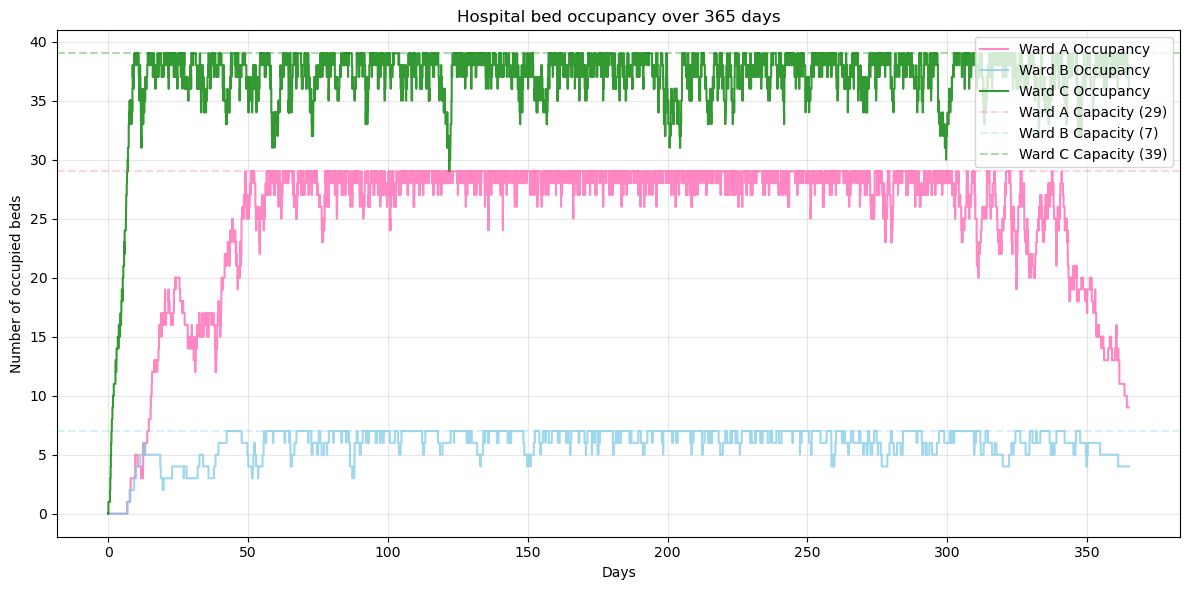

In [93]:
# We start by runnngin the run_simulation_plot function with the optimal 75-bed distribution
plot_data = run_simulation_plot(29, 7, 39)

# Extracting the data for plotting
times = [event[1] for event in plot_data]

# To find how many people are in Ward A,  we sum column 0 of the flow matrix
occupied_A = [np.sum(event[0][:, 0]) for event in plot_data]
occupied_B = [np.sum(event[0][:, 1]) for event in plot_data]
occupied_C = [np.sum(event[0][:, 2]) for event in plot_data]

# Creating the plot
plt.figure(figsize=(12, 6))

# We use plt.step because hospital beds fill up in discrete steps
plt.step(times, occupied_A, label='Ward A Occupancy', alpha=0.8, where='post', color = 'hotpink')
plt.step(times, occupied_B, label='Ward B Occupancy', alpha=0.8, where='post', color = 'skyblue')
plt.step(times, occupied_C, label='Ward C Occupancy', alpha=0.8, where='post', color = 'green')

# Adding threshold lines to show the maximum capacity of each ward
plt.axhline(y=29, color='hotpink', linestyle='--', alpha=0.3, label='Ward A Capacity (29)')
plt.axhline(y=7, color='skyblue', linestyle='--', alpha=0.3, label='Ward B Capacity (7)')
plt.axhline(y=39, color='green', linestyle='--', alpha=0.3, label='Ward C Capacity (39)')

plt.title('Hospital bed occupancy over 365 days')
plt.xlabel('Days')
plt.ylabel('Number of occupied beds')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()